# **Loading the data**

In [1]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np
import shutil
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from sklearn.model_selection import StratifiedKFold
from skimage import exposure
import pickle
import random
import sys
import gc

In [2]:
K = 5
EPOCHS = 30
BATCH_SIZE = 32
LR = 1e-4
Class_Names = ["Glioma", "Meningioma", "Pituitary"]
all_experiments = {}

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
base_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή"

In [5]:
sys.path.append('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή')
from PreProcessing_Script import dataset_preparation

In [6]:
cnn_root_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model"

def create_experiment_folders(experiment_name):
    experiment_dir = os.path.join(cnn_root_dir, experiment_name)
    results_dir = os.path.join(experiment_dir, "results")
    images_dir = os.path.join(results_dir, "images")
    models_dir = os.path.join(results_dir, "models")
    report_dir = os.path.join(results_dir, "report")

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    return {
        "experiment_dir": experiment_dir,
        "results_dir": results_dir,
        "images_dir": images_dir,
        "models_dir": models_dir,
        "report_dir": report_dir
    }

combined_roc_cnn_path = os.path.join(cnn_root_dir, "combined_roc_cnn.png")
cnn_experiments_path  = os.path.join(cnn_root_dir, "cnn_experiments.pkl")

In [7]:
x_train_val_raw = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/x_train_val_raw.pkl","rb"))
x_test_raw      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/x_test_raw.pkl","rb"))
y_train_val_int = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/y_train_val_int.pkl","rb"))
y_test_int      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/y_test_int.pkl","rb"))

In [8]:
input_shape = (x_train_val_raw.shape[1], x_train_val_raw.shape[2])

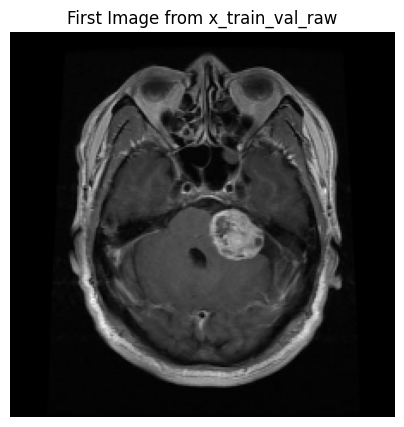

In [9]:
# Select the first image from x_train_val_raw
# Assuming x_train_val_raw is a NumPy array of images
image_to_display = x_train_val_raw[0]

plt.figure(figsize=(5, 5))
plt.imshow(image_to_display, cmap='gray')
plt.title('First Image from x_train_val_raw')
plt.axis('off') # Hide axes ticks and labels
plt.show()

# Saving

In [10]:
def get_save_paths(model_or_experiment_name):
    if isinstance(model_or_experiment_name, str):
        experiment_name = model_or_experiment_name
    else:
        experiment_name = model_or_experiment_name.experiment_name

    folders = create_experiment_folders(experiment_name)

    paths = {
        "model": os.path.join(folders["models_dir"], f"{experiment_name}.keras"),
        "train_loss": os.path.join(folders["images_dir"], f"{experiment_name}_train_loss.png"),
        "train_accuracy": os.path.join(folders["images_dir"], f"{experiment_name}_train_accuracy.png"),
        "confusion_matrix": os.path.join(folders["images_dir"], f"{experiment_name}_confusion_matrix.png"),
        "roc_curve": os.path.join(folders["images_dir"], f"{experiment_name}_roc_curve.png"),
        "auc_report": os.path.join(folders["report_dir"], f"{experiment_name}_auc_report.txt"),
        "classification_report": os.path.join(folders["report_dir"], f"{experiment_name}_classification_report.txt"),
        "confusion_matrix_txt": os.path.join(folders["report_dir"], f"{experiment_name}_confusion_matrix.txt"),
        "kfold_metrics": os.path.join(folders["report_dir"], f"{experiment_name}_kfold_metrics.txt"),
        "roc_raw_data": os.path.join(folders["report_dir"], f"{experiment_name}_roc_raw_data")
    }

    return paths

# **Plots**

In [11]:
def acc_and_loss(history, model_experiment_name, save_paths=None):
  hist = history.history

  epochs_acc = np.arange(1, len(hist["accuracy"])+1)
  epochs_loss = np.arange(1, len(hist["loss"])+1)

  fig_acc, ax_acc = plt.subplots(figsize=(10,5), dpi = 120)
  ax_acc.plot(
      epochs_acc,
      hist["accuracy"],
      label = "Training Accuracy",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_accuracy" in hist:
    ax_acc.plot(
        epochs_acc,
        hist["val_accuracy"],
        label = "Validation Accuracy",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_acc.set_title(f"{model_experiment_name} - Accuracy")
  ax_acc.set_xlabel("Epochs")
  ax_acc.set_ylabel("Accuracy")
  ax_acc.grid(True, alpha = 0.3)
  ax_acc.legend()
  fig_acc.tight_layout()

  if save_paths is not None and "train_accuracy" in save_paths:
    fig_acc.savefig(save_paths["train_accuracy"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_acc)

  fig_loss, ax_loss = plt.subplots(figsize=(10,5), dpi = 120)
  ax_loss.plot(
      epochs_loss,
      hist["loss"],
      label = "Training Loss",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_loss" in hist:
    ax_loss.plot(
        epochs_loss,
        hist["val_loss"],
        label = "Validation Loss",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_loss.set_title(f"{model_experiment_name} - Loss")
  ax_loss.set_xlabel("Epochs")
  ax_loss.set_ylabel("Loss")
  ax_loss.grid(True, alpha = 0.3)
  ax_loss.legend()
  fig_loss.tight_layout()

  if save_paths is not None and "train_loss" in save_paths:
    fig_loss.savefig(save_paths["train_loss"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_loss)

  print('Loss:')
  print('  - loss [training dataset]: {:.3f}'.format(hist['loss'][-1]))
  if 'val_loss' in hist:
      print('  - loss [validation dataset]: {:.3f}'.format(hist['val_loss'][-1]))

  print('')
  print('Accuracy:')
  print('  - accuracy [training dataset]: {:.2f}%'.format(100 * hist['accuracy'][-1]))
  if 'val_accuracy' in hist:
      print('  - accuracy [validation dataset]: {:.2f}%'.format(100 * hist['val_accuracy'][-1]))

  return fig_acc, fig_loss

In [12]:
def plot_kfold(histories, title_prefix=''):

  min_len = min([len(h['loss']) for h in histories])

  train_loss = np.array([h['loss'][:min_len] for h in histories])
  val_loss = np.array([h['val_loss'][:min_len] for h in histories])

  train_acc = np.array([h['accuracy'][:min_len] for h in histories])
  val_acc = np.array([h['val_accuracy'][:min_len] for h in histories])

  epochs = np.arange(1, min_len+1)

  plt.figure()
  plt.plot(epochs, train_loss.mean(axis=0), label='Training Loss')
  plt.plot(epochs, val_loss.mean(axis=0), label='Validation Loss')
  plt.title(f'{title_prefix} - Loss')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

  plt.figure()
  plt.plot(epochs, train_acc.mean(axis=0), label='Training Accuracy')
  plt.plot(epochs, val_acc.mean(axis=0), label='Validation Accuracy')
  plt.title(f'{title_prefix} - Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

In [13]:
def plot_confusion_matrix(cm, Class_Names, save_path=None):

  plt.figure()
  plt.colorbar(plt.imshow(cm))
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.xticks(np.arange(len(Class_Names)), Class_Names, rotation=45)
  plt.yticks(np.arange(len(Class_Names)), Class_Names)

  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      plt.text(j, i, str(cm[i, j]), ha="center", va="center")

  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

In [14]:
def plot_roc_auc(y_true_int, y_prob, class_names, save_path=None):
  n_classes = len(class_names)

  y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))

  fpr = dict()
  tpr = dict()
  roc_auc = dict()

  plt.figure(figsize=(10, 10), dpi=120)

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

  plt.plot([0,1], [0,1], 'k--', linewidth=1)

  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve (One-vs-Rest)")
  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)
  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

  macro_auc = np.mean(list(roc_auc.values()))
  print("\nAUC per Class: ")
  for i in range(n_classes):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")
  print(f"Macro AUC: {macro_auc:.4f}")

  return roc_auc, macro_auc


In [15]:
def plot_combined_roc(experiments, class_names, save_path=None):
    n_classes = len(class_names)

    plt.figure(figsize=(10, 10), dpi=120)

    for exp_name, exp_data in experiments.items():
        data = np.load(exp_data["roc_raw_data"])

        all_fpr  = np.linspace(0, 1, 100)
        mean_tpr = np.zeros_like(all_fpr)

        for i in range(n_classes):
            fpr = data[f"fpr_{i}"]
            tpr = data[f"tpr_{i}"]
            mean_tpr += np.interp(all_fpr, fpr, tpr)

        mean_tpr /= n_classes
        macro_auc = exp_data["macro_auc"]

        plt.plot(all_fpr, mean_tpr, linewidth=2,
                 label=f"{exp_name} (Macro AUC = {macro_auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison (Macro Average)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

# Compile Function

In [16]:
def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=["accuracy"]
    )
    return model

# CNN Models

## Base CNN Model

In [17]:
def cnn_model_base(use_augmentation = None, model_key="cnn"):

  inputs = layers.Input(shape=(224, 224, 1))

  x = inputs

  if use_augmentation:
    augmentation = build_augmentation()
    x = augmentation(x)

  x = layers.Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu")(x)
  x = layers.Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)

  x = layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)

  x = layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)

  x = layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)
  x = layers.GlobalMaxPooling2D()(x)

  outputs = layers.Dense(3, activation = 'softmax')(x)

  model_cnn_base = tf.keras.Model(inputs = inputs, outputs = outputs, name=model_key)

  model_cnn_base.model_key = "cnn"
  model_cnn_base.experiment_name = model_key

  return model_cnn_base

model_cnn_base = cnn_model_base()

initial_weight = model_cnn_base.get_weights()

In [18]:
model_cnn_base.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 637,667 (2.43 MB)

 Trainable params: 637,667 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

## Data Augmentation

In [19]:
def build_augmentation():
  return tf.keras.Sequential([
      layers.RandomRotation(0.01),
      layers.RandomTranslation(height_factor=0.005, width_factor=0.005),
      layers.RandomZoom(0.01),
  ], name="data_augmentation")

## Builder

In [20]:
def build_model(cfg):
  model = cfg["builder"]()
  model.model_key = cfg["model_key"]
  model.experiment_name = cfg["experiment_name"]
  return model

# List Of Experiments

In [21]:
EXPERIMENTS = {
    "cnn_base": {
        "builder": lambda: cnn_model_base(
            use_augmentation=False,
            model_key="cnn_base"
        ),
        "model_key": "cnn",
        "experiment_name": "cnn_base",
        "use_augmentation": False
    },
    "cnn_aug": {
        "builder": lambda: cnn_model_base(
            use_augmentation=True,
            model_key="cnn_aug"
        ),
        "model_key": "cnn",
        "experiment_name": "cnn_aug",
        "use_augmentation": True
    }
}

# **Dataset Preparation**

In [22]:
def make_ds(X, y, batch_size=32, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
      ds = ds.shuffle(len(X), seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Functions for K-Fold, Training and Evaluation

In [23]:
def kfold(x_raw, y, cfg, K, BATCH_SIZE, LR, EPOCHS):
  skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

  fold_metrics = []
  fold_histories = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(x_raw, y), start=1):
    print(f"\n=== {cfg["experiment_name"]} / Fold {fold}/{K} ===")

    x_tr_raw = x_raw[train_idx]
    x_va_raw = x_raw[val_idx]
    y_tr = y[train_idx]
    y_va = y[val_idx]

    x_tr, x_va = dataset_preparation(
        cfg["model_key"],
        x_raw[train_idx],
        x_raw[val_idx]
    )

    x_tr_4D = np.expand_dims(x_tr, axis=-1)
    x_va_4D = np.expand_dims(x_va, axis=-1)

    train_ds = make_ds(x_tr_4D, y_tr, batch_size=BATCH_SIZE, training=True)
    val_ds = make_ds(x_va_4D, y_va, batch_size=BATCH_SIZE, training=False)

    fold_model = build_model(cfg)
    fold_model = compile_model(fold_model, lr=LR)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            min_delta=0.001
        )
    ]

    history = fold_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose = 1,
        callbacks=callbacks
    )

    val_loss, val_acc = fold_model.evaluate(val_ds, verbose = 0)

    fold_metrics.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    fold_histories.append({
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"]
    })

    del x_tr, y_tr, x_va, y_va, train_ds, val_ds, fold_model, history, x_tr_4D, x_va_4D
    gc.collect()
    tf.keras.backend.clear_session()

  return fold_metrics, fold_histories

In [24]:
def train_test(cfg, save_model = True):

  model = build_model(cfg)
  save_paths = get_save_paths(model)

  x_train_raw, x_val_raw, y_train_int, y_val_int = train_test_split(
      x_train_val_raw,
      y_train_val_int,
      test_size=0.2,
      random_state=42,
      stratify=y_train_val_int
  )

  x_train_pp, x_val_pp = dataset_preparation(cfg["model_key"],
                                              x_train_raw,
                                              x_val_raw)
  _, x_test_pp = dataset_preparation(cfg["model_key"],
                                     x_train_val_raw[:1],
                                     x_test_raw)

  x_train_pp_4D = np.expand_dims(x_train_pp, axis=-1)
  x_val_pp_4D = np.expand_dims(x_val_pp, axis=-1)
  x_test_pp_4D = np.expand_dims(x_test_pp, axis=-1)

  train_ds = make_ds(x_train_pp_4D, y_train_int, batch_size=BATCH_SIZE, training=True)
  val_ds = make_ds(x_val_pp_4D, y_val_int, batch_size = BATCH_SIZE, training=False)
  test_ds = make_ds(x_test_pp_4D, y_test_int, batch_size=BATCH_SIZE, training=False)

  model.set_weights(initial_weight)

  model = compile_model(model, lr=LR)

  callbacks = [
      tf.keras.callbacks.EarlyStopping(
          monitor='val_accuracy',
          patience=5,
          restore_best_weights=True,
          min_delta=0.001)
  ]

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=EPOCHS,
      verbose = 1,
      callbacks = callbacks
  )

  if save_model:
    model.save(save_paths["model"])

  test_loss, test_accuracy = model.evaluate(test_ds, verbose = 0)

  y_prob = model.predict(test_ds, verbose=0)
  y_pred = np.argmax(y_prob, axis=1)

  cm = confusion_matrix(y_test_int, y_pred)

  print("Test Loss: ", float(test_loss))
  print("Test Accuracy: ", float(test_accuracy))

  report = classification_report(
      y_test_int,
      y_pred,
      target_names=Class_Names
  )

  print("Classification Report:")
  print(report)

  roc_auc_dict, macro_auc = plot_roc_auc(
      y_test_int,
      y_prob,
      Class_Names,
      save_paths["roc_curve"]
  )

  y_true_bin = label_binarize(y_test_int, classes=np.arange(len(Class_Names)))
  save_dict  = {}
  for i in range(len(Class_Names)):
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    save_dict[f"fpr_{i}"] = fpr_i
    save_dict[f"tpr_{i}"] = tpr_i
  np.savez(save_paths["roc_raw_data"], **save_dict)

  with open(save_paths["classification_report"], "w") as f:
    f.write(report)
    f.write("\n")
    f.write(f"Test Loss: {float(test_loss):.4f}\n")
    f.write(f"Test Accuracy: {float(test_accuracy):.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  with open(save_paths["confusion_matrix_txt"], "w") as f:
    f.write(str(cm))

  with open(save_paths["auc_report"], "w") as f:
    for i, class_name in enumerate(Class_Names):
      f.write(f"{class_name}: AUC = {roc_auc_dict[i]:.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  plot_confusion_matrix(cm, Class_Names, save_paths["confusion_matrix"])

  acc_and_loss(history, model.experiment_name, save_paths=save_paths)

  del x_train_raw, x_val_raw, x_train_pp, x_val_pp, x_test_pp, x_train_pp_4D, x_val_pp_4D, x_test_pp_4D, train_ds, val_ds, test_ds
  gc.collect()

  return model, history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, save_paths["roc_raw_data"]

# Base CNN

In [25]:
cfg_base = EXPERIMENTS["cnn_base"]

## K-Fold(K=5)

In [26]:
base_metrics, base_histories = kfold(x_raw=x_train_val_raw,
                                     y=y_train_val_int,
                                     cfg = cfg_base,
                                     K=K,
                                     BATCH_SIZE = BATCH_SIZE,
                                     LR = LR,
                                     EPOCHS = EPOCHS)


=== cnn_base / Fold 1/5 ===
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 361ms/step - accuracy: 0.4903 - loss: 1.0390 - val_accuracy: 0.6232 - val_loss: 0.9780
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.6464 - loss: 0.7720 - val_accuracy: 0.6660 - val_loss: 0.8009
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.7071 - loss: 0.6288 - val_accuracy: 0.7291 - val_loss: 0.6647
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.7378 - loss: 0.5901 - val_accuracy: 0.6680 - val_loss: 0.7162
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.7541 - loss: 0.5430 - val_accuracy: 0.7108 - val_loss: 0.6032
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.7770 - loss: 0.4873 - val_accuracy: 0.7067 - val_loss: 0.6411
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.7770 - loss: 0.4829 - val_accuracy: 0.7230 - val_loss: 0.5969
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 130

In [27]:
base_accuracy = [m["val_acc"] for m in base_metrics]
base_losses = [m["val_loss"] for m in base_metrics]

print("Fold Accuracies:", base_accuracy)
print("Mean Accuracy :", np.mean(base_accuracy))
print("Std Accuracy  :", np.std(base_accuracy))
print("Mean Loss     :", np.mean(base_losses))
print("Std Loss      :", np.std(base_losses))

Fold Accuracies: [0.7291242480278015, 0.9265305995941162, 0.8306122422218323, 0.8877550959587097, 0.8204081654548645]
Mean Accuracy : 0.8388860702514649
Std Accuracy  : 0.06712271152309846
Mean Loss     : 0.46193587183952334
Std Loss      : 0.13138961099430332


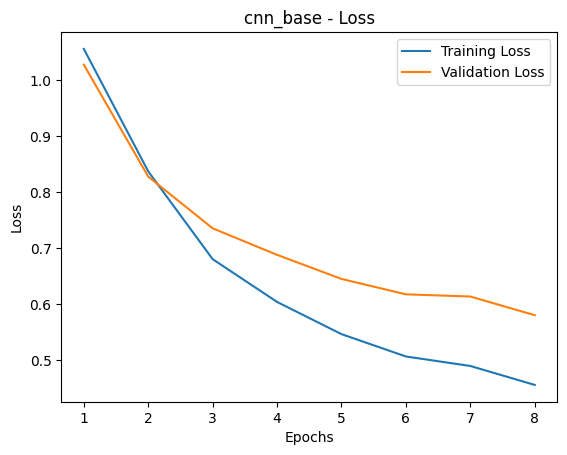

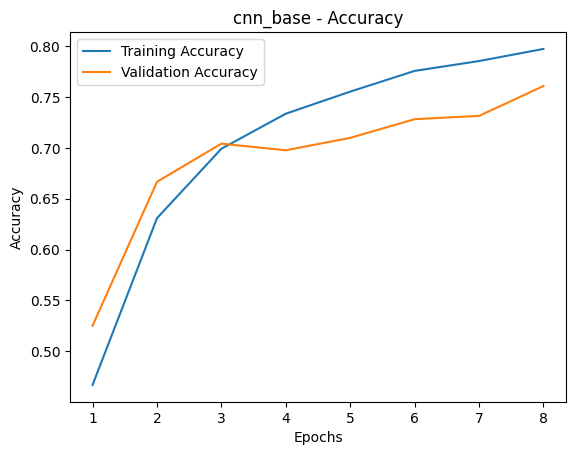

In [28]:
plot_kfold(base_histories, title_prefix=cfg_base["experiment_name"])

In [29]:
save_paths = get_save_paths(cfg_base["experiment_name"])

with open(save_paths["kfold_metrics"], "w") as f:
    for row in base_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(base_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(base_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(base_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(base_losses):.4f}\n")

In [30]:
del base_metrics
del base_histories
gc.collect()

10508

## Training + Evaluation

Using preprocessing: baseline
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 262ms/step - accuracy: 0.4750 - loss: 1.0591 - val_accuracy: 0.4664 - val_loss: 1.0402
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.6138 - loss: 0.8472 - val_accuracy: 0.6680 - val_loss: 0.8853
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.6811 - loss: 0.6910 - val_accuracy: 0.7189 - val_loss: 0.7225
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.7541 - loss: 0.5503 - val_accuracy: 0.7434 - val_loss: 0.6430
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.7571 - loss: 0.5341 - val_accuracy: 0.7271 - val_loss: 0.6520
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.8143 - loss: 0.4459 - val_accuracy: 0.7495 - val_loss: 0.5639
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.8092 - loss: 0.4535 - val_accuracy: 0.7475 - val_loss: 0.5892
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 12

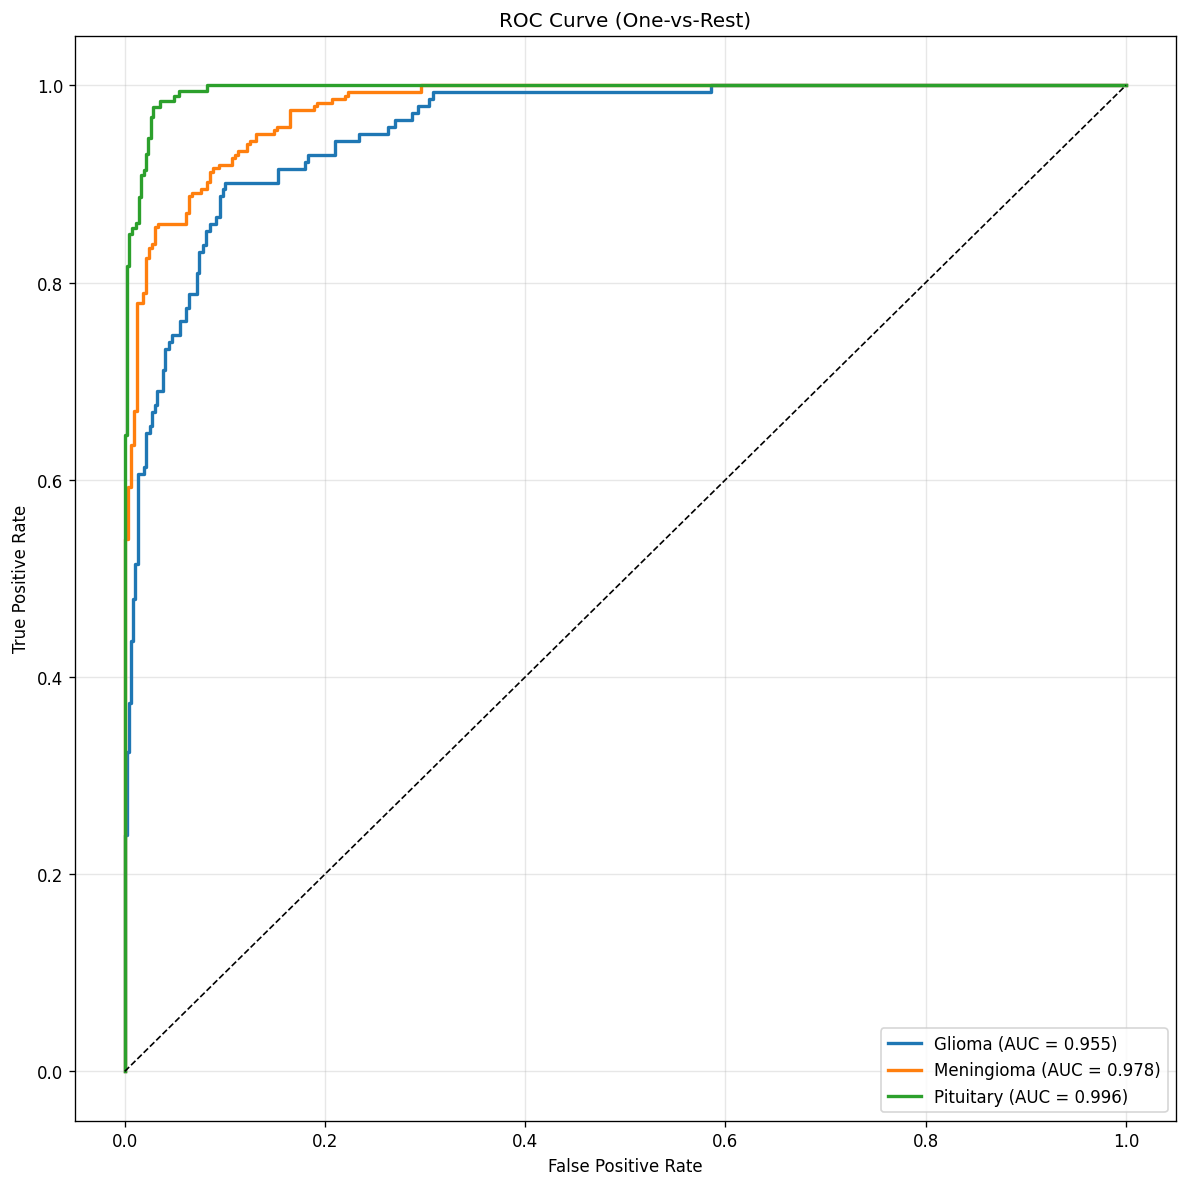


AUC per Class: 
Glioma: 0.9553
Meningioma: 0.9782
Pituitary: 0.9958
Macro AUC: 0.9764


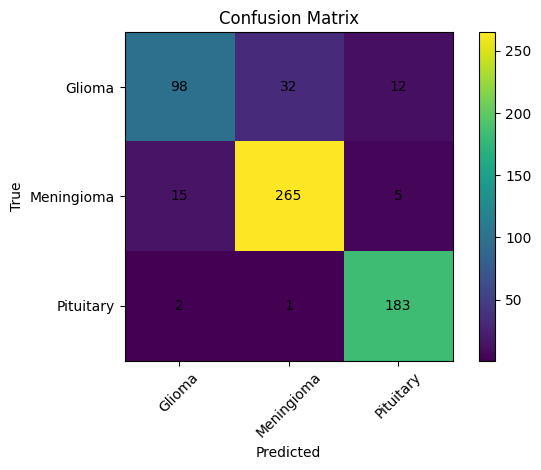

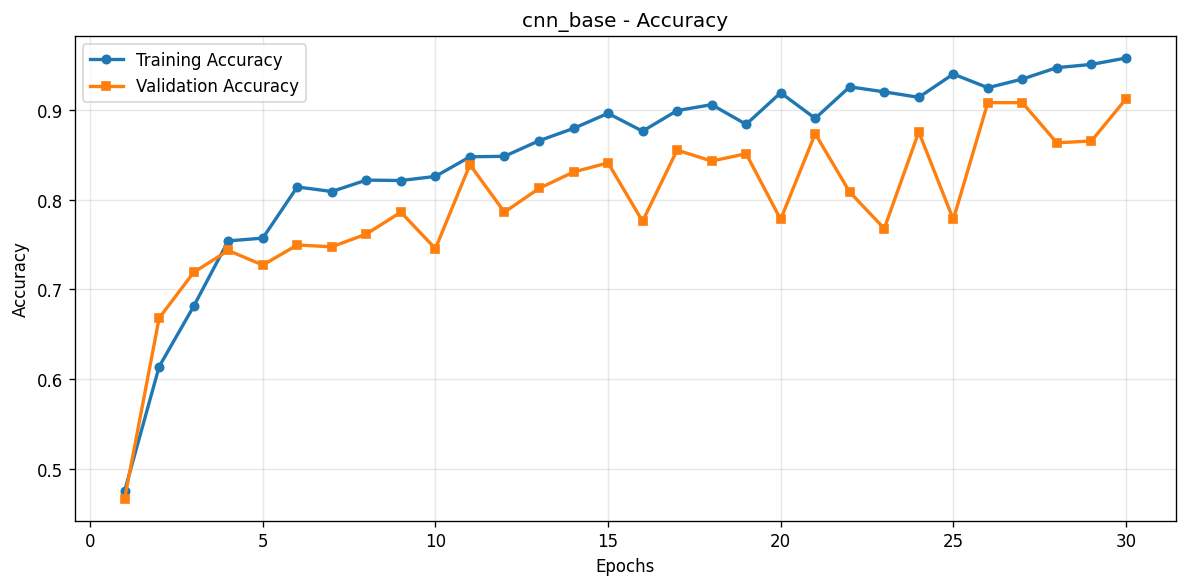

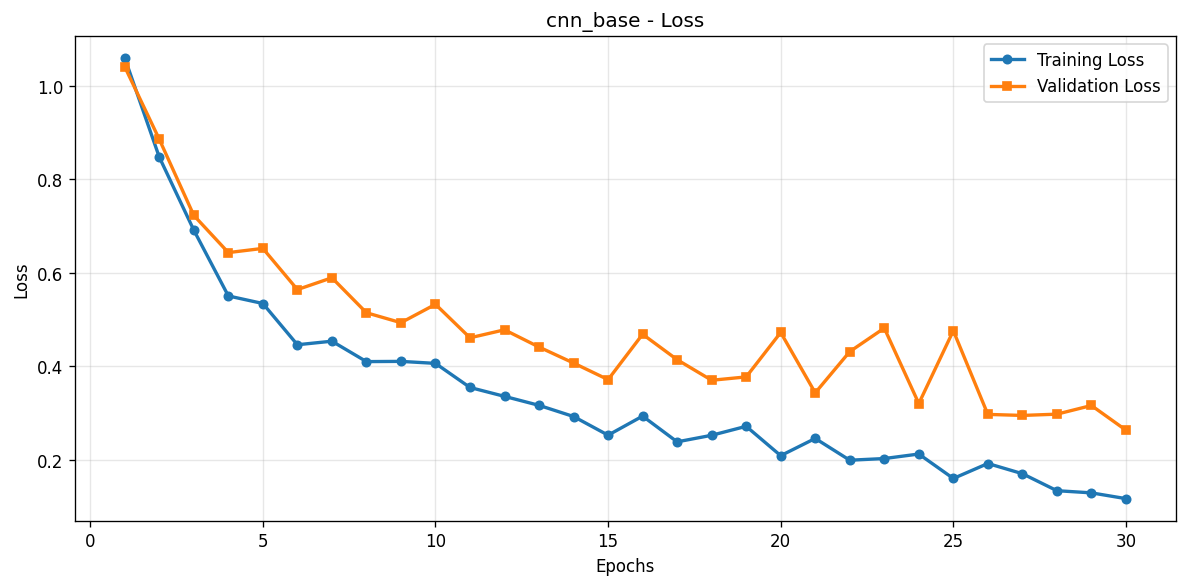

Loss:
  - loss [training dataset]: 0.117
  - loss [validation dataset]: 0.263

Accuracy:
  - accuracy [training dataset]: 95.82%
  - accuracy [validation dataset]: 91.24%


In [31]:
final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, roc_raw_data_path = train_test(
    cfg = cfg_base,
    save_model = True
)

all_experiments["CNN Base"] = {
    "macro_auc":    macro_auc,
    "roc_raw_data": roc_raw_data_path + ".npz"
}

In [32]:
del final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, cfg_base, roc_raw_data_path
gc.collect()

10016

In [33]:
tf.keras.backend.clear_session()

# Base CNN with Augmentation

In [34]:
cfg_aug = EXPERIMENTS["cnn_aug"]

## K-Fold(K=5)

In [35]:
aug_metrics, aug_histories = kfold(x_raw=x_train_val_raw,
                                     y=y_train_val_int,
                                     cfg = cfg_aug,
                                     K=K,
                                     BATCH_SIZE = BATCH_SIZE,
                                     LR = LR,
                                     EPOCHS = EPOCHS)


=== cnn_aug / Fold 1/5 ===
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 202ms/step - accuracy: 0.4653 - loss: 1.0606 - val_accuracy: 0.4664 - val_loss: 1.0496
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - accuracy: 0.5847 - loss: 0.9067 - val_accuracy: 0.6823 - val_loss: 0.8705
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - accuracy: 0.6577 - loss: 0.7769 - val_accuracy: 0.7169 - val_loss: 0.8011
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.7015 - loss: 0.6869 - val_accuracy: 0.6538 - val_loss: 0.7401
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.7158 - loss: 0.6410 - val_accuracy: 0.7332 - val_loss: 0.6805
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.7429 - loss: 0.5609 - val_accuracy: 0.7210 - val_loss: 0.6813
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.7852 - loss: 0.4953 - val_accuracy: 0.7658 - val_loss: 0.5886
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1

In [36]:
aug_accuracy = [m["val_acc"] for m in aug_metrics]
aug_losses = [m["val_loss"] for m in aug_metrics]

print("Fold Accuracies:", aug_accuracy)
print("Mean Accuracy :", np.mean(aug_accuracy))
print("Std Accuracy  :", np.std(aug_accuracy))
print("Mean Loss     :", np.mean(aug_losses))
print("Std Loss      :", np.std(aug_losses))

Fold Accuracies: [0.8879836797714233, 0.9265305995941162, 0.7795918583869934, 0.8571428656578064, 0.8408163189888]
Mean Accuracy : 0.8584130644798279
Std Accuracy  : 0.049068240778781545
Mean Loss     : 0.4301163136959076
Std Loss      : 0.1111453146877488


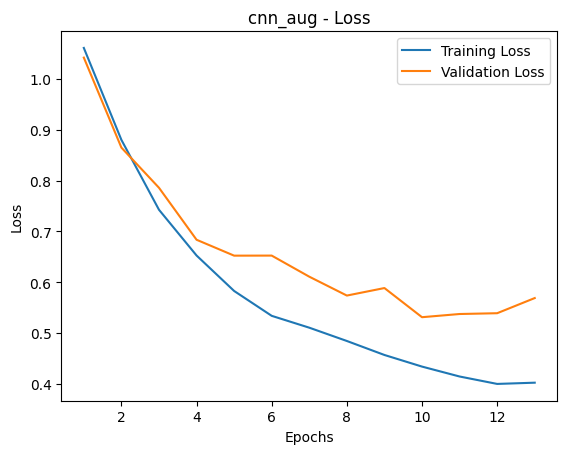

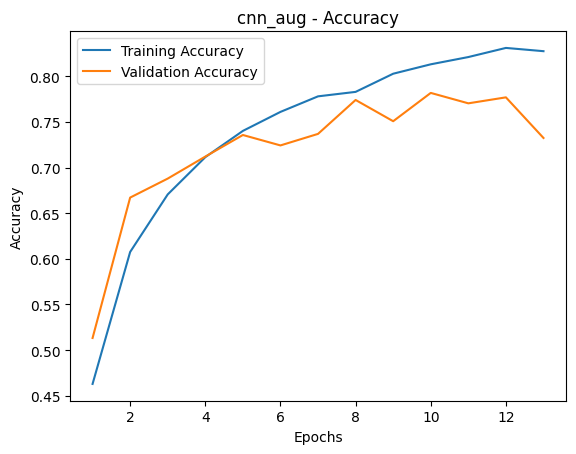

In [37]:
plot_kfold(aug_histories, title_prefix=cfg_aug["experiment_name"])

In [38]:
save_paths = get_save_paths(cfg_aug["experiment_name"])

with open(save_paths["kfold_metrics"], "w") as f:
    for row in aug_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(aug_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(aug_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(aug_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(aug_losses):.4f}\n")

In [39]:
del aug_metrics
del aug_histories
gc.collect()

11142

## Training + Evaluation

Using preprocessing: baseline
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 15s 179ms/step - accuracy: 0.4786 - loss: 1.0581 - val_accuracy: 0.4725 - val_loss: 1.0337
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.6316 - loss: 0.8394 - val_accuracy: 0.6701 - val_loss: 0.8905
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.6832 - loss: 0.6815 - val_accuracy: 0.7067 - val_loss: 0.7086
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.7607 - loss: 0.5470 - val_accuracy: 0.7413 - val_loss: 0.6373
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.7673 - loss: 0.5243 - val_accuracy: 0.7352 - val_loss: 0.6250
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.8117 - loss: 0.4473 - val_accuracy: 0.7413 - val_loss: 0.5653
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.8010 - loss: 0.4641 - val_accuracy: 0.7434 - val_loss: 0.5839
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━

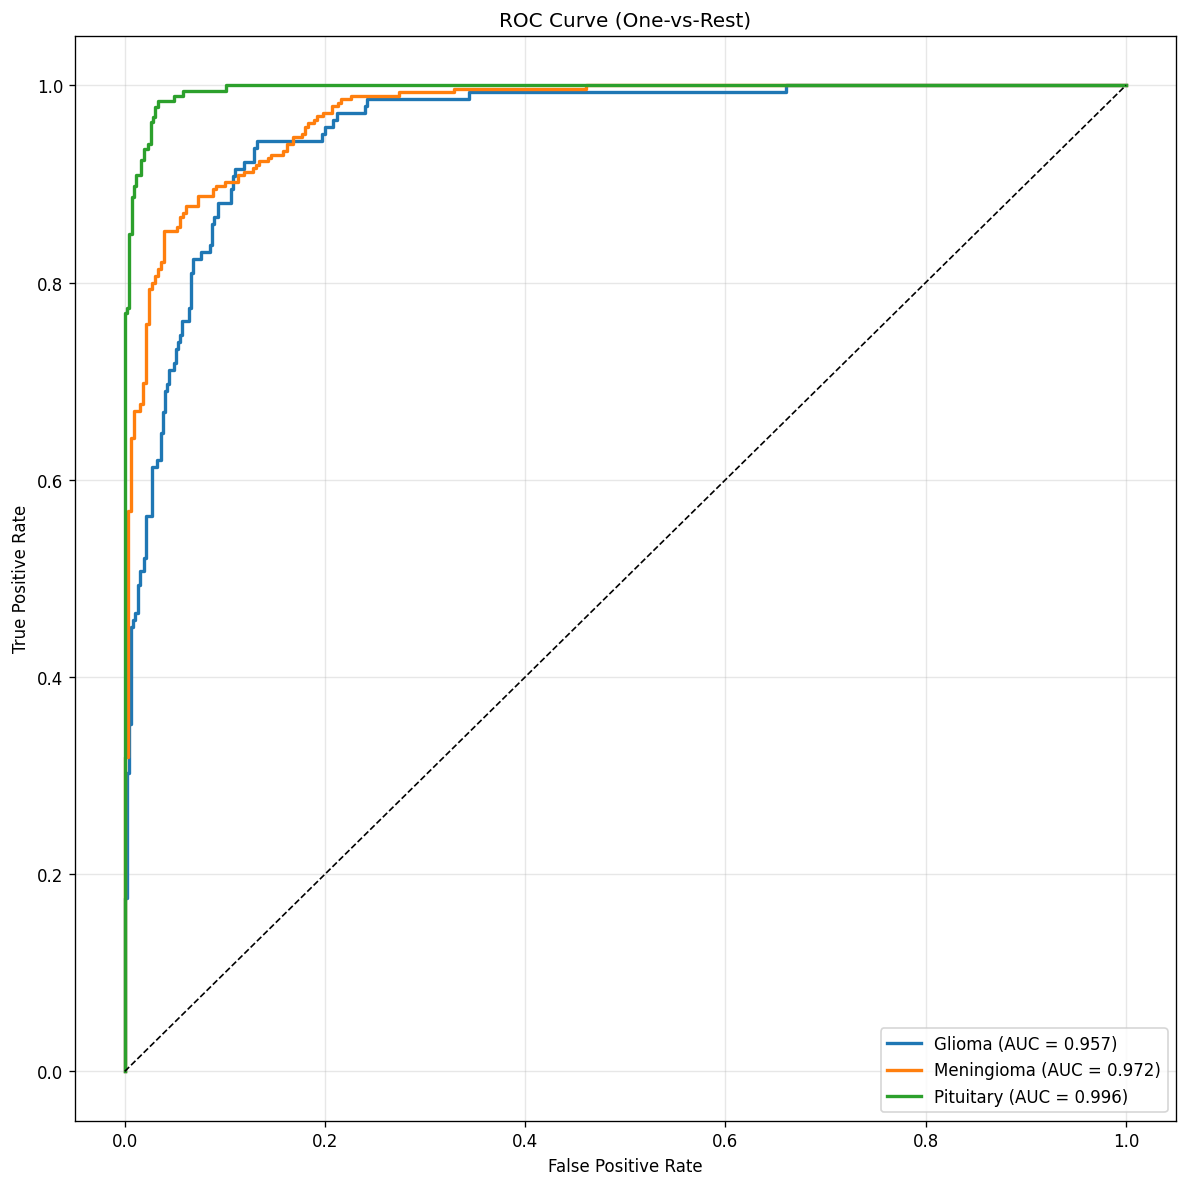


AUC per Class: 
Glioma: 0.9565
Meningioma: 0.9718
Pituitary: 0.9962
Macro AUC: 0.9748


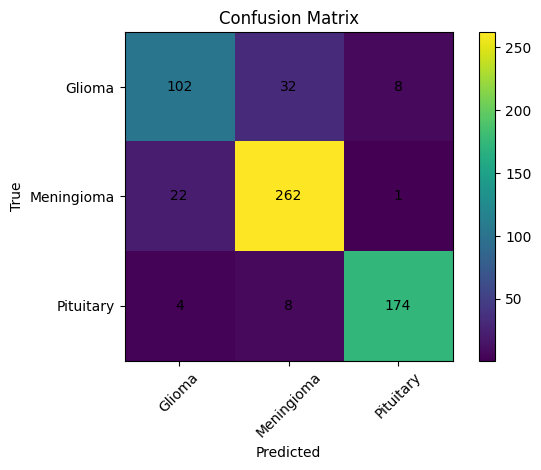

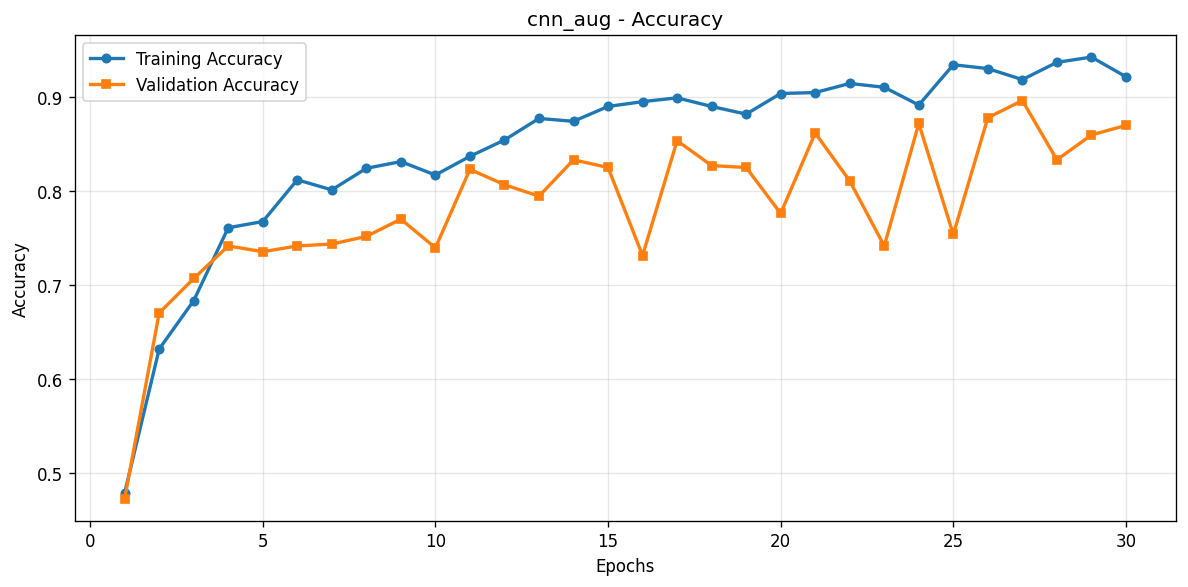

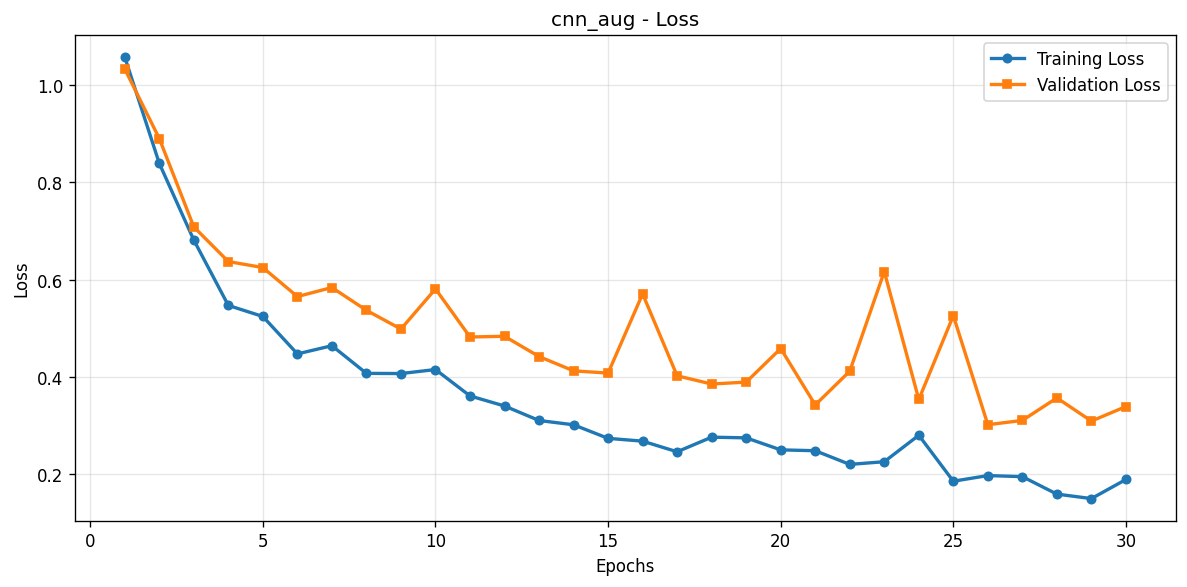

Loss:
  - loss [training dataset]: 0.189
  - loss [validation dataset]: 0.339

Accuracy:
  - accuracy [training dataset]: 92.14%
  - accuracy [validation dataset]: 86.97%


In [40]:
final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, roc_raw_data_path = train_test(
    cfg = cfg_aug,
    save_model = True
)

all_experiments["CNN Aug"] = {
    "macro_auc":    macro_auc,
    "roc_raw_data": roc_raw_data_path + ".npz"
}

In [41]:
del final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, cfg_aug
gc.collect()

9930

In [42]:
tf.keras.backend.clear_session()

## CNN Base Model vs CNN Base Model With Augmentation

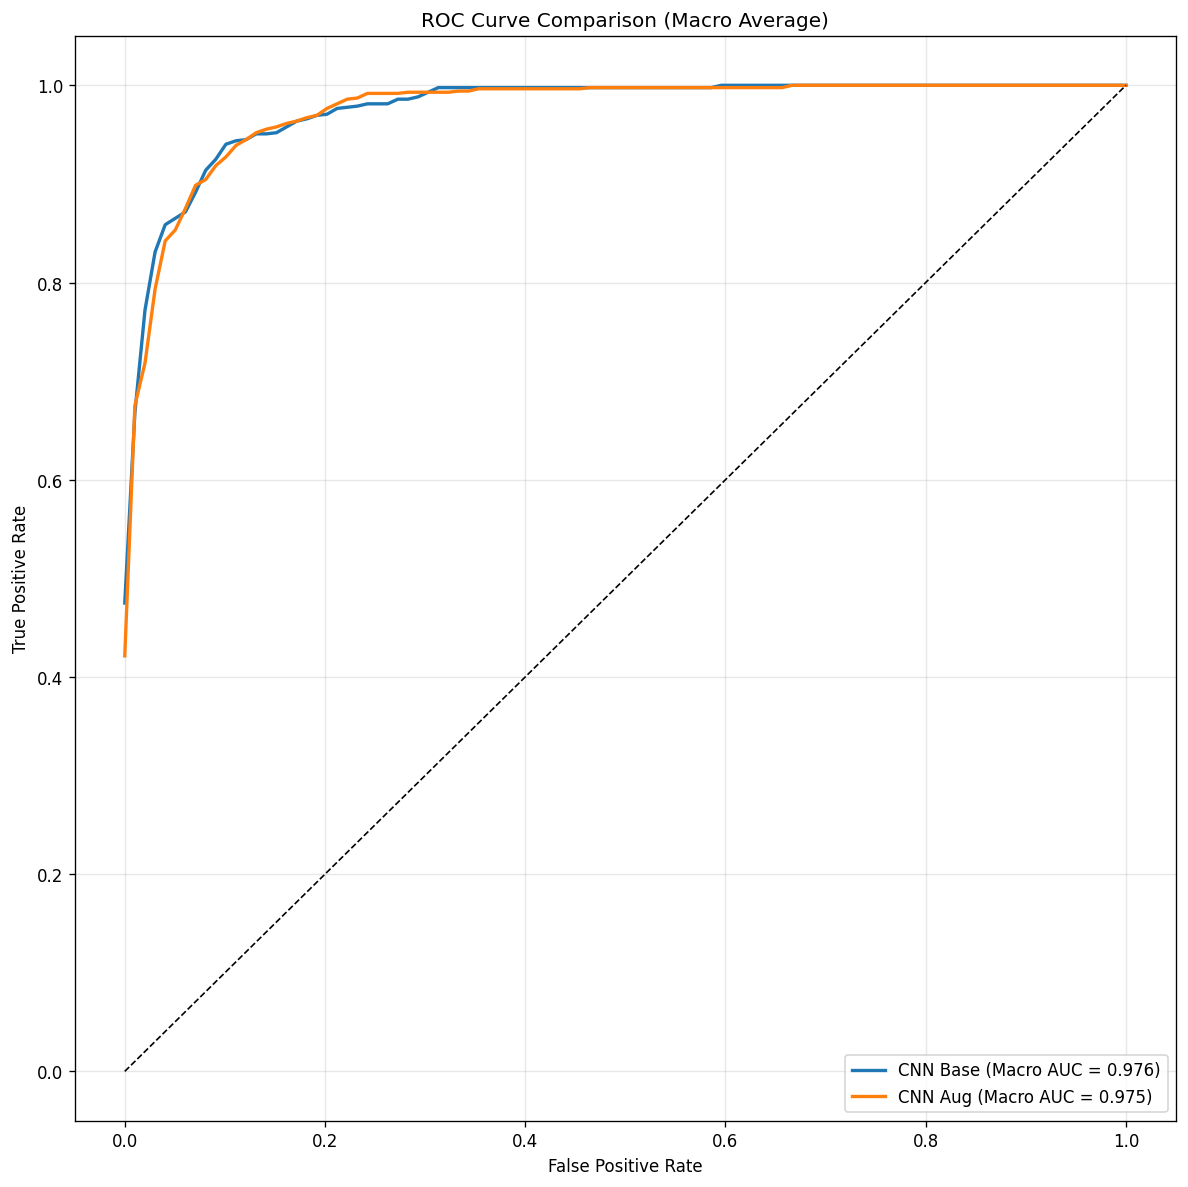

Best CNN experiment: CNN Base (Macro AUC = 0.976)
Saved to: /content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/cnn_experiments.pkl


In [43]:
# Combined ROC — CNN Base vs CNN Aug
plot_combined_roc(all_experiments, Class_Names, save_path=combined_roc_cnn_path)

# Εκτύπωση καλύτερου experiment
best_name, best_data = max(all_experiments.items(), key=lambda x: x[1]["macro_auc"])
print(f"Best CNN experiment: {best_name} (Macro AUC = {best_data['macro_auc']:.3f})")

with open(cnn_experiments_path, "wb") as f:
    pickle.dump(all_experiments, f)

print(f"Saved to: {cnn_experiments_path}")